<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_17th_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from datasets import load_dataset

ds = load_dataset("RachidAb02/Finance-Accounting")

In [9]:
import pandas as pd
import numpy as np
import re
from datasets import load_dataset

# Re-load the data
ds = load_dataset('RachidAb02/Finance-Accounting', split='train')
df = ds.to_pandas()

# Basic Cleaning
df_cleaned = df.copy()
df_cleaned = df_cleaned.drop_duplicates(subset=['question'], keep='first')

text_cols = ['question', 'answer', 'prompt', 'response']
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].replace('Unknown', np.nan)

def normalize_text(text):
    if pd.isna(text): return text
    return re.sub(r'\s+', ' ', str(text).lower()).strip()

for col in text_cols:
    df_cleaned[col] = df_cleaned[col].apply(normalize_text)

print(f"Data re-loaded and cleaned. Shape: {df_cleaned.shape}")

Data re-loaded and cleaned. Shape: (84, 4)


In [10]:
from transformers import MarianTokenizer, MarianMTModel, pipeline
import torch

# 1. Translation Setup
model_name = 'Helsinki-NLP/opus-mt-fr-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_batch(texts):
    tokenized = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    translated_tokens = model.generate(**tokenized)
    return [tokenizer.decode(t, skip_special_tokens=True) for t in translated_tokens]

print("Translating text to English...")
# Process columns if they have content
for col in ['question', 'answer']:
    valid_mask = df_cleaned[col].notna()
    if valid_mask.any():
        df_cleaned.loc[valid_mask, f'{col}_en'] = translate_batch(df_cleaned.loc[valid_mask, col].tolist())

# 2. Sentiment Analysis Setup
print("Running Sentiment Analysis...")
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

for col in ['question_en', 'answer_en']:
    if col in df_cleaned.columns:
        results = df_cleaned[col].fillna('').apply(lambda x: sentiment_analyzer(x)[0] if x else {'label': 'NEUTRAL', 'score': 0.0})
        df_cleaned[f'{col.replace("_en", "")}_sentiment_label'] = results.apply(lambda x: x['label'])
        df_cleaned[f'{col.replace("_en", "")}_sentiment_score'] = results.apply(lambda x: x['score'])

print("Sentiment Analysis complete.")

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

Translating text to English...
Running Sentiment Analysis...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Analysis complete.


In [11]:
print('--- Sentiment Summary for Questions ---')
display(df_cleaned['question_sentiment_label'].value_counts())

print('\n--- Sentiment Summary for Answers ---')
display(df_cleaned['answer_sentiment_label'].value_counts())

print('\nSample of Results:')
display(df_cleaned[['question_en', 'question_sentiment_label', 'answer_en', 'answer_sentiment_label']].head())

--- Sentiment Summary for Questions ---


,count
question_sentiment_label,
NEGATIVE,73
POSITIVE,11



--- Sentiment Summary for Answers ---


,count
answer_sentiment_label,
NEGATIVE,50
POSITIVE,34



Sample of Results:


,question_en,question_sentiment_label,answer_en,answer_sentiment_label
0,What is an accounting balance sheet?,NEGATIVE,the accounting balance sheet is a financial do...,POSITIVE
1,What is a profit and loss account?,NEGATIVE,the profit and loss account is a financial doc...,POSITIVE
2,What is the difference between an asset and a ...,NEGATIVE,an asset represents the assets and rights held...,POSITIVE
3,how is the profit margin calculated?,NEGATIVE,the profit margin is calculated by dividing th...,NEGATIVE
4,What is a depreciation?,NEGATIVE,amortisation is the accounting finding of the ...,NEGATIVE


Pearson Correlation between Question and Answer Sentiment Scores: -0.0859


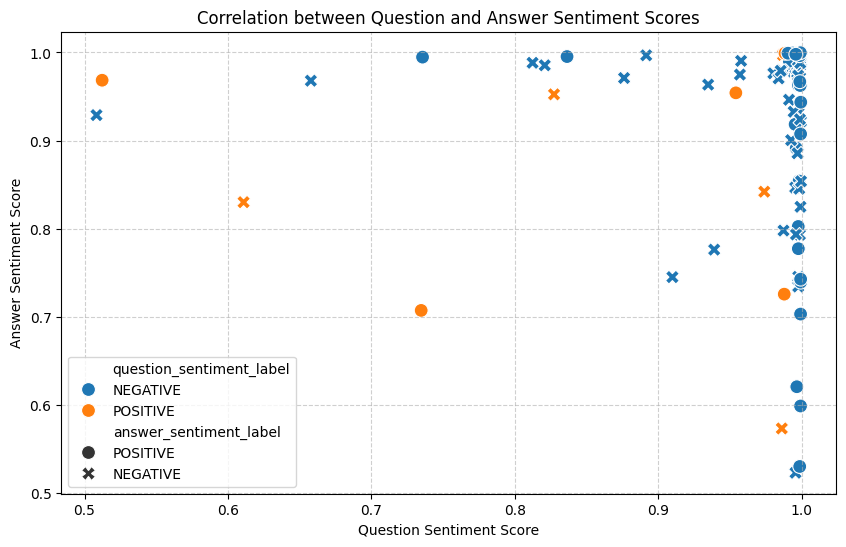

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation
correlation = df_cleaned['question_sentiment_score'].corr(df_cleaned['answer_sentiment_score'])
print(f"Pearson Correlation between Question and Answer Sentiment Scores: {correlation:.4f}")

# Visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='question_sentiment_score', y='answer_sentiment_score', hue='question_sentiment_label', style='answer_sentiment_label', s=100)
plt.title('Correlation between Question and Answer Sentiment Scores')
plt.xlabel('Question Sentiment Score')
plt.ylabel('Answer Sentiment Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Contingency Table (Frequencies):


answer_sentiment_label,NEGATIVE,POSITIVE,Total
question_sentiment_label,,,
NEGATIVE,45,28,73
POSITIVE,5,6,11
Total,50,34,84


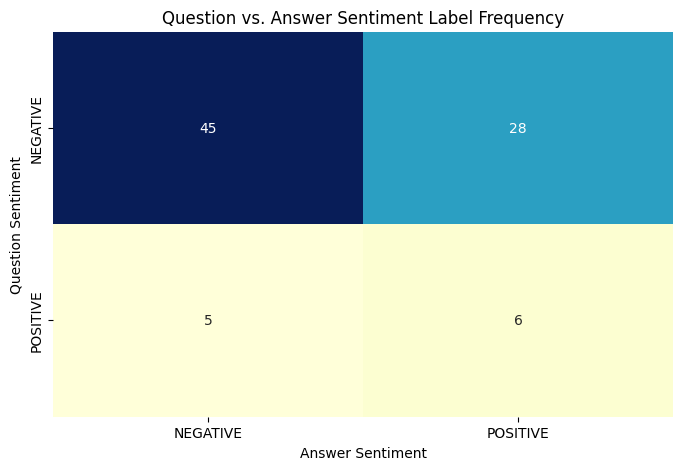

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the contingency table
contingency_table = pd.crosstab(
    df_cleaned['question_sentiment_label'],
    df_cleaned['answer_sentiment_label'],
    margins=True,
    margins_name="Total"
)

print("Contingency Table (Frequencies):")
display(contingency_table)

# Visualize with a heatmap for better intuition
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(df_cleaned['question_sentiment_label'], df_cleaned['answer_sentiment_label']),
            annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Question vs. Answer Sentiment Label Frequency')
plt.xlabel('Answer Sentiment')
plt.ylabel('Question Sentiment')
plt.show()

Basic Statistics for Sentiment Score Difference:


,sentiment_score_diff
count,84.000000
mean,-0.054768
std,0.165777
min,-0.472921
25%,-0.146621
50%,-0.021468
75%,0.000936
max,0.456231


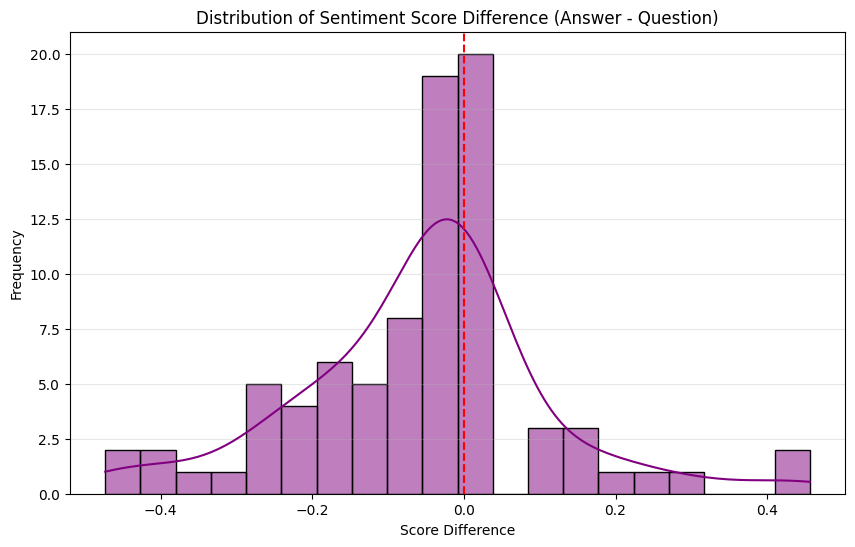

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference (Answer Score - Question Score)
# Note: This compares the raw 'confidence' scores.
df_cleaned['sentiment_score_diff'] = df_cleaned['answer_sentiment_score'] - df_cleaned['question_sentiment_score']

print("Basic Statistics for Sentiment Score Difference:")
display(df_cleaned['sentiment_score_diff'].describe())

# Visualize the distribution of differences
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['sentiment_score_diff'], kde=True, bins=20, color='purple')
plt.title('Distribution of Sentiment Score Difference (Answer - Question)')
plt.xlabel('Score Difference')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [17]:
from scipy import stats

# Perform a one-sample t-test
# Null Hypothesis: The mean difference is 0
t_stat, p_value = stats.ttest_1samp(df_cleaned['sentiment_score_diff'].dropna(), 0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: The difference is statistically significant (reject the null hypothesis).")
    print("There is a non-zero shift in sentiment intensity between questions and answers.")
else:
    print("\nResult: The difference is NOT statistically significant (fail to reject the null hypothesis).")
    print("The observed difference could likely be due to random chance.")

T-statistic: -3.0279
P-value: 0.0033

Result: The difference is statistically significant (reject the null hypothesis).
There is a non-zero shift in sentiment intensity between questions and answers.


In [20]:
# ============================================
# 💰 Finance-Accounting Analysis Pipeline
# ============================================

# Step 1: Install & Import Libraries
!pip install shap datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             r2_score, mean_squared_error)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import shap

# Step 2: Load Dataset from Hugging Face
ds = load_dataset("RachidAb02/Finance-Accounting", split="train")
df = ds.to_pandas()   # Convert to Pandas DataFrame

# Step 3: Inspect Dataset
print(df.shape)
print(df.info())
print(df.head())

# Step 4: Handle Missing Values
# Fill numeric NaNs with mean (if any numeric columns exist)
df.fillna(df.mean(numeric_only=True), inplace=True)
# Fill object NaNs with "Unknown"
# This fills NaNs in all other columns, assuming numeric NaNs are already handled.
df.fillna("Unknown", inplace=True)

# Step 5: Exploratory Data Analysis
numeric_df_for_corr = df.select_dtypes(include=np.number)
if not numeric_df_for_corr.empty:
    sns.heatmap(numeric_df_for_corr.corr(), cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("Skipping correlation heatmap: No numeric columns found in the dataset for correlation analysis.")

# Step 6: Outlier Detection
numeric_cols_for_outliers = df.select_dtypes(include=np.number).columns
if not numeric_cols_for_outliers.empty:
    for col in numeric_cols_for_outliers:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        print(f"{col}: {len(outliers)} outliers")
else:
    print("Skipping outlier detection: No numeric columns found in the dataset.")


# Step 7: Feature Engineering (example)
# df['log_amount'] = np.log1p(df['Amount'])

# Step 8: Define Target(s)
# The pipeline is designed for numeric targets for regression or object targets for classification.
# However, the loaded dataset currently contains only object columns (text data).
# The predefined targets ("Revenue", "Expenses", "Profit") do not exist in this dataset.
targets = ["Revenue", "Expenses", "Profit"]  # original hardcoded targets

# Filter for targets that exist in df and are suitable for the planned analysis.
# For this pipeline, assuming it's for numeric prediction or simple classification.
# Given the current data (all object type), no targets will be valid for the subsequent steps.
valid_analysis_targets = []
for t in targets:
    if t in df.columns:
        if pd.api.types.is_numeric_dtype(df[t]):
            valid_analysis_targets.append(t)
        # If classification of object type columns was robustly handled, add 'elif pd.api.types.is_object_dtype(df[t]): valid_analysis_targets.append(t)'
        # For now, assuming the regression/classification part needs numeric target or specific object targets.

if not valid_analysis_targets:
    print("\nWarning: The loaded dataset 'RachidAb02/Finance-Accounting' contains only text columns and does not have the expected numeric target columns ('Revenue', 'Expenses', 'Profit') for this analysis pipeline.")
    print("Skipping modeling, clustering, PCA, and SHAP steps due to absence of valid numeric targets.")
else:
    # Step 9–15: Loop through each target
    for target in valid_analysis_targets:
        print(f"\n================ Analyzing target: {target} ================\n")

        # Select only numeric features for X, dropping the target itself.
        X = df.drop(columns=[target]).select_dtypes(include=np.number)
        y = df[target]

        if X.empty:
            print(f"Skipping analysis for target '{target}': No numeric features left after dropping the target.")
            continue

        # Train-Test Split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Modeling (Assuming target `y` is numeric as per `valid_analysis_targets` filtering)
        # Original code had `if y.dtype == "object":` for LogisticRegression, else LinearRegression.
        # With `valid_analysis_targets` filtered to numeric, this implies regression.
        # If `valid_analysis_targets` could include object types for classification, then the `if y.dtype == "object":`
        # block would be relevant and would need to handle X (features) appropriately (e.g., one-hot encoding if X was also object).
        # For now, only regression path is relevant for numeric targets.
        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        print("R^2:", r2_score(y_test, y_pred))
        print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
        plt.scatter(y_test, y_pred)
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title(f"Regression Predictions for {target}")
        plt.show()

        # Clustering
        if X_train_scaled.shape[1] > 0: # Ensure there's at least one feature for clustering
            kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for KMeans future compatibility
            clusters = kmeans.fit_predict(X_train_scaled)
            # The original line 'df[f"Cluster_{target}"] = clusters' is problematic due to index misalignment
            # and is not strictly necessary for plotting.
            plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=clusters, cmap="Set2")
            plt.title(f"KMeans Clusters for {target}")
            plt.show()
        else:
            print(f"Skipping clustering for target '{target}': Not enough features for KMeans.")

        # PCA
        if X_train_scaled.shape[1] >= 2: # PCA requires at least 2 components for a 2D plot
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_train_scaled)
            plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="Set1") # using clusters from KMeans
            plt.title(f"PCA Projection for {target}")
            plt.show()
        elif X_train_scaled.shape[1] == 1: # Handle 1D case for PCA
            pca = PCA(n_components=1)
            X_pca = pca.fit_transform(X_train_scaled)
            plt.scatter(X_pca[:,0], np.zeros_like(X_pca[:,0]), c=clusters, cmap="Set1")
            plt.title(f"PCA Projection (1D) for {target}")
            plt.show()
        else:
            print(f"Skipping PCA for target '{target}': Not enough features for PCA (need at least 1).")

        # Explainability (SHAP)
        # Check if model was fitted and if there's data for SHAP analysis.
        if (hasattr(model, 'coef_') or hasattr(model, 'feature_importances_')) and X_train_scaled.shape[0] > 0 and X_test_scaled.shape[0] > 0:
            try:
                shap_sample_size = min(100, X_test_scaled.shape[0])
                if shap_sample_size > 0 and X_train_scaled.shape[0] > 0:
                    # Using the entire X_train_scaled as background for explainer, which can be computationally intensive for large datasets.
                    # For a more robust approach with large datasets, consider a sample or different masker.
                    explainer = shap.Explainer(model, X_train_scaled)
                    shap_values = explainer(X_test_scaled[:shap_sample_size])
                    shap.summary_plot(shap_values, X_test[:shap_sample_size], plot_type="bar", show=False)
                    plt.title(f"SHAP Values for {target}")
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Skipping SHAP for target '{target}': Not enough data for SHAP analysis.")
            except Exception as e:
                print(f"An error occurred during SHAP analysis for target '{target}': {e}")
        else:
            print(f"Skipping SHAP for target '{target}': Model type not suitable or no data for SHAP explanation.")

# Step 16: Save Results
try:
    df.to_csv("finance_analysis_multi_targets.csv", index=False)
    print("✅ Finance-Accounting pipeline complete. Results saved to 'finance_analysis_multi_targets.csv'.")
except Exception as e:
    print(f"An error occurred while saving results: {e}")
    print("The DataFrame 'df' might contain data types that are not easily convertible to CSV, or other issues (e.g., new columns added with incompatible types).")


(132, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   answer    84 non-null     object
 1   prompt    48 non-null     object
 2   question  84 non-null     object
 3   response  48 non-null     object
dtypes: object(4)
memory usage: 4.3+ KB
None
                                              answer prompt  \
0  Le bilan comptable est un document financier q...   None   
1  Le compte de résultat est un document financie...   None   
2  Un actif représente les biens et droits détenu...   None   
3  La marge bénéficiaire se calcule en divisant l...   None   
4  L'amortissement est la constatation comptable ...   None   

                                            question response  
0                   Qu'est-ce qu'un bilan comptable?     None  
1                Qu'est-ce qu'un compte de résultat?     None  
2  Quelle est la différence entre un actif 

In [21]:
df_loaded_csv = pd.read_csv('finance_analysis_multi_targets.csv')
print("Loaded 'finance_analysis_multi_targets.csv' into df_loaded_csv:")
display(df_loaded_csv.head())

Loaded 'finance_analysis_multi_targets.csv' into df_loaded_csv:


,answer,prompt,question,response
0,Le bilan comptable est un document financier q...,Unknown,Qu'est-ce qu'un bilan comptable?,Unknown
1,Le compte de résultat est un document financie...,Unknown,Qu'est-ce qu'un compte de résultat?,Unknown
2,Un actif représente les biens et droits détenu...,Unknown,Quelle est la différence entre un actif et un ...,Unknown
3,La marge bénéficiaire se calcule en divisant l...,Unknown,Comment calcule-t-on la marge bénéficiaire?,Unknown
4,L'amortissement est la constatation comptable ...,Unknown,Qu'est-ce qu'un amortissement?,Unknown


In [22]:
df = df_loaded_csv.copy()
print("Renamed df_loaded_csv to df. Displaying the first 5 rows of df:")
display(df.head())

Renamed df_loaded_csv to df. Displaying the first 5 rows of df:


,answer,prompt,question,response
0,Le bilan comptable est un document financier q...,Unknown,Qu'est-ce qu'un bilan comptable?,Unknown
1,Le compte de résultat est un document financie...,Unknown,Qu'est-ce qu'un compte de résultat?,Unknown
2,Un actif représente les biens et droits détenu...,Unknown,Quelle est la différence entre un actif et un ...,Unknown
3,La marge bénéficiaire se calcule en divisant l...,Unknown,Comment calcule-t-on la marge bénéficiaire?,Unknown
4,L'amortissement est la constatation comptable ...,Unknown,Qu'est-ce qu'un amortissement?,Unknown


## Text Data Analysis

Since the dataset contains only text columns, let's explore them using some basic NLP techniques.

In [23]:
# Display a sample of the text data
print("Sample of 'question' column:")
display(df['question'].head())

print("\nSample of 'answer' column:")
display(df['answer'].head())

print("\nSample of 'prompt' column:")
display(df['prompt'].head())

print("\nSample of 'response' column:")
display(df['response'].head())

Sample of 'question' column:


,question
0,Qu'est-ce qu'un bilan comptable?
1,Qu'est-ce qu'un compte de résultat?
2,Quelle est la différence entre un actif et un ...
3,Comment calcule-t-on la marge bénéficiaire?
4,Qu'est-ce qu'un amortissement?



Sample of 'answer' column:


,answer
0,Le bilan comptable est un document financier q...
1,Le compte de résultat est un document financie...
2,Un actif représente les biens et droits détenu...
3,La marge bénéficiaire se calcule en divisant l...
4,L'amortissement est la constatation comptable ...



Sample of 'prompt' column:


,prompt
0,Unknown
1,Unknown
2,Unknown
3,Unknown
4,Unknown



Sample of 'response' column:


,response
0,Unknown
1,Unknown
2,Unknown
3,Unknown
4,Unknown


In [24]:
# Check for duplicate questions
duplicate_questions = df[df.duplicated(subset=['question'], keep=False)]

if not duplicate_questions.empty:
    print(f"Found {len(duplicate_questions)} rows with duplicate questions:")
    display(duplicate_questions.sort_values(by='question'))
else:
    print("No duplicate questions found in the dataset.")

Found 50 rows with duplicate questions:


,answer,prompt,question,response
58,Des exemples de comptes de provisions dans la ...,Unknown,Donnez des exemples de comptes de provisions d...,Unknown
67,Des exemples de comptes de provisions dans la ...,Unknown,Donnez des exemples de comptes de provisions d...,Unknown
109,Unknown,Comment la gestion des risques peut-elle contr...,Unknown,La gestion des risques éclaire la prise de déc...
110,Unknown,Quels sont les avantages d'une culture d'entre...,Unknown,Une culture axée sur la gestion du risque enco...
111,Unknown,Expliquez comment la gestion du risque peut ai...,Unknown,La gestion du risque aide une entreprise à se ...
112,Unknown,Quels sont les risques liés aux partenariats c...,Unknown,Les risques liés aux partenariats incluent les...
113,Unknown,Donnez des exemples de risques liés à la chaîn...,Unknown,Des exemples incluent les retards de livraison...
114,Unknown,Comment une entreprise peut-elle évaluer les r...,Unknown,L'évaluation des risques liés aux marchés inte...
115,Unknown,Quelles sont les étapes clés de la préparation...,Unknown,Les étapes clés comprennent l'identification d...
116,Unknown,Comment une entreprise peut-elle gérer les ris...,Unknown,La gestion des risques liés à la réputation im...


### Word Count and Unique Word Count for Text Columns

In [25]:
for col in ['question', 'answer', 'prompt', 'response']:
    if col in df.columns:
        print(f"\n--- Column: {col} ---")
        # Fill NaN values with empty strings before processing
        text_data = df[col].fillna('').astype(str)

        # Word count
        df[f'{col}_word_count'] = text_data.apply(lambda x: len(x.split()))
        print(f"Average word count: {df[f'{col}_word_count'].mean():.2f}")
        print(f"Max word count: {df[f'{col}_word_count'].max()}")
        print(f"Min word count: {df[f'{col}_word_count'].min()}")

        # Unique word count (simple tokenization)
        all_words = ' '.join(text_data).lower().split()
        unique_words = set(all_words)
        print(f"Total unique words: {len(unique_words)}")


--- Column: question ---
Average word count: 7.82
Max word count: 23
Min word count: 1
Total unique words: 196

--- Column: answer ---
Average word count: 15.45
Max word count: 34
Min word count: 1
Total unique words: 589

--- Column: prompt ---
Average word count: 5.98
Max word count: 21
Min word count: 1
Total unique words: 231

--- Column: response ---
Average word count: 13.83
Max word count: 46
Min word count: 1
Total unique words: 636


## Text Data Cleaning

Based on the initial analysis, let's clean the text data by handling duplicate questions, 'Unknown' values, and performing basic text normalization.

In [26]:
import pandas as pd
import numpy as np
import re

# 1. Remove duplicate questions
# Keep the first occurrence of a question if its answer is not 'Unknown'
# If all answers for a duplicate question are 'Unknown', keep the first one anyway.

initial_rows = len(df)
df_cleaned = df.copy()

# Identify rows where 'answer' is 'Unknown' for potential duplicates
mask_unknown_answer = df_cleaned['answer'] == 'Unknown'

# Sort to ensure consistent keeping (e.g., if we want to prioritize non-unknown answers)
# For simplicity, we'll just drop duplicates directly, keeping the first occurrence.
# If there are duplicate questions, we prioritize the one with a known answer, if not, then the first one.

# Step 1: Separate known answers from unknown answers for duplicate handling
df_known_answers = df_cleaned[~mask_unknown_answer]
df_unknown_answers = df_cleaned[mask_unknown_answer]

# Step 2: Drop duplicates from known answers, keeping the first. This is our primary set.
df_known_answers_unique = df_known_answers.drop_duplicates(subset=['question'], keep='first')

# Step 3: From the unknown answers, add only those questions that are not already in our unique known answers set.
# This prevents adding an 'Unknown' answer if a known answer for the same question already exists.
questions_with_known_answers = df_known_answers_unique['question'].unique()
df_unknown_answers_unique = df_unknown_answers[~df_unknown_answers['question'].isin(questions_with_known_answers)]
df_unknown_answers_unique = df_unknown_answers_unique.drop_duplicates(subset=['question'], keep='first')

# Step 4: Concatenate them back. The known answers already have unique questions.
df_cleaned = pd.concat([df_known_answers_unique, df_unknown_answers_unique], ignore_index=True)

print(f"Removed {initial_rows - len(df_cleaned)} rows with duplicate questions (prioritizing known answers).")

# 2. Handle 'Unknown' string values by converting them to NaN (or dropping if preferred)
# For text analysis, 'Unknown' is a placeholder and often shouldn't be treated as meaningful text.
text_cols = ['question', 'answer', 'prompt', 'response']
for col in text_cols:
    # Replace the 'Unknown' placeholder with actual NaN for better handling in NLP steps
    df_cleaned[col] = df_cleaned[col].replace('Unknown', np.nan)

# 3. Basic Text Normalization (e.g., lowercase, remove extra spaces)

def normalize_text(text):
    if pd.isna(text): # Handle NaN values
        return text
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    # Add more normalization steps here if needed (e.g., remove punctuation, diacritics)
    return text

print("\nPerforming text normalization (lowercase, remove extra spaces)...")
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].apply(normalize_text)

print("Text cleaning complete. Displaying info for the cleaned DataFrame:")
print(df_cleaned.info())
display(df_cleaned.head())

Removed 48 rows with duplicate questions (prioritizing known answers).

Performing text normalization (lowercase, remove extra spaces)...
Text cleaning complete. Displaying info for the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   answer               83 non-null     object
 1   prompt               1 non-null      object
 2   question             83 non-null     object
 3   response             1 non-null      object
 4   question_word_count  84 non-null     int64 
 5   answer_word_count    84 non-null     int64 
 6   prompt_word_count    84 non-null     int64 
 7   response_word_count  84 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 5.4+ KB
None


,answer,prompt,question,response,question_word_count,answer_word_count,prompt_word_count,response_word_count
0,le bilan comptable est un document financier q...,NaN,qu'est-ce qu'un bilan comptable?,NaN,4,22,1,1
1,le compte de résultat est un document financie...,NaN,qu'est-ce qu'un compte de résultat?,NaN,5,19,1,1
2,un actif représente les biens et droits détenu...,NaN,quelle est la différence entre un actif et un ...,NaN,10,22,1,1
3,la marge bénéficiaire se calcule en divisant l...,NaN,comment calcule-t-on la marge bénéficiaire?,NaN,5,25,1,1
4,l'amortissement est la constatation comptable ...,NaN,qu'est-ce qu'un amortissement?,NaN,3,16,1,1


In [27]:
# 1. Remove duplicate questions
# Keep the first occurrence of a question if its answer is not 'Unknown'
# If all answers for a duplicate question are 'Unknown', keep the first one anyway.

initial_rows = len(df)
df_cleaned = df.copy()

# Identify rows where 'answer' is 'Unknown' for potential duplicates
mask_unknown_answer = df_cleaned['answer'] == 'Unknown'

# Sort to ensure consistent keeping (e.g., if we want to prioritize non-unknown answers)
# For simplicity, we'll just drop duplicates directly, keeping the first occurrence.
# If there are duplicate questions, we prioritize the one with a known answer, if not, then the first one.

# Step 1: Separate known answers from unknown answers for duplicate handling
df_known_answers = df_cleaned[~mask_unknown_answer]
df_unknown_answers = df_cleaned[mask_unknown_answer]

# Step 2: Drop duplicates from known answers, keeping the first. This is our primary set.
df_known_answers_unique = df_known_answers.drop_duplicates(subset=['question'], keep='first')

# Step 3: From the unknown answers, add only those questions that are not already in our unique known answers set.
# This prevents adding an 'Unknown' answer if a known answer for the same question already exists.
questions_with_known_answers = df_known_answers_unique['question'].unique()
df_unknown_answers_unique = df_unknown_answers[~df_unknown_answers['question'].isin(questions_with_known_answers)]
df_unknown_answers_unique = df_unknown_answers_unique.drop_duplicates(subset=['question'], keep='first')

# Step 4: Concatenate them back. The known answers already have unique questions.
df_cleaned = pd.concat([df_known_answers_unique, df_unknown_answers_unique], ignore_index=True)

print(f"Removed {initial_rows - len(df_cleaned)} rows with duplicate questions (prioritizing known answers).")

# 2. Handle 'Unknown' string values by converting them to NaN (or dropping if preferred)
# For text analysis, 'Unknown' is a placeholder and often shouldn't be treated as meaningful text.
text_cols = ['question', 'answer', 'prompt', 'response']
for col in text_cols:
    # Replace the 'Unknown' placeholder with actual NaN for better handling in NLP steps
    df_cleaned[col] = df_cleaned[col].replace('Unknown', np.nan)

# 3. Basic Text Normalization (e.g., lowercase, remove extra spaces)
import re

def normalize_text(text):
    if pd.isna(text): # Handle NaN values
        return text
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    # Add more normalization steps here if needed (e.g., remove punctuation, diacritics)
    return text

print("\nPerforming text normalization (lowercase, remove extra spaces)...")
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].apply(normalize_text)

print("Text cleaning complete. Displaying info for the cleaned DataFrame:")
print(df_cleaned.info())
display(df_cleaned.head())

Removed 48 rows with duplicate questions (prioritizing known answers).

Performing text normalization (lowercase, remove extra spaces)...
Text cleaning complete. Displaying info for the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   answer               83 non-null     object
 1   prompt               1 non-null      object
 2   question             83 non-null     object
 3   response             1 non-null      object
 4   question_word_count  84 non-null     int64 
 5   answer_word_count    84 non-null     int64 
 6   prompt_word_count    84 non-null     int64 
 7   response_word_count  84 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 5.4+ KB
None


,answer,prompt,question,response,question_word_count,answer_word_count,prompt_word_count,response_word_count
0,le bilan comptable est un document financier q...,NaN,qu'est-ce qu'un bilan comptable?,NaN,4,22,1,1
1,le compte de résultat est un document financie...,NaN,qu'est-ce qu'un compte de résultat?,NaN,5,19,1,1
2,un actif représente les biens et droits détenu...,NaN,quelle est la différence entre un actif et un ...,NaN,10,22,1,1
3,la marge bénéficiaire se calcule en divisant l...,NaN,comment calcule-t-on la marge bénéficiaire?,NaN,5,25,1,1
4,l'amortissement est la constatation comptable ...,NaN,qu'est-ce qu'un amortissement?,NaN,3,16,1,1


### Re-evaluating Word Count and Unique Word Count after Cleaning

Let's re-run the word count and unique word count analysis on the `df_cleaned` DataFrame to see the impact of our cleaning steps.

In [28]:
for col in ['question', 'answer', 'prompt', 'response']:
    if col in df_cleaned.columns:
        print(f"\n--- Column: {col} (Cleaned) ---")
        # Fill NaN values with empty strings before processing
        text_data = df_cleaned[col].fillna('').astype(str)

        # Word count
        df_cleaned[f'{col}_word_count_cleaned'] = text_data.apply(lambda x: len(x.split()))
        print(f"Average word count: {df_cleaned[f'{col}_word_count_cleaned'].mean():.2f}")
        print(f"Max word count: {df_cleaned[f'{col}_word_count_cleaned'].max()}")
        print(f"Min word count: {df_cleaned[f'{col}_word_count_cleaned'].min()}")

        # Unique word count (simple tokenization)
        all_words = ' '.join(text_data).lower().split()
        unique_words = set(all_words)
        print(f"Total unique words: {len(unique_words)}")


--- Column: question (Cleaned) ---
Average word count: 11.58
Max word count: 23
Min word count: 0
Total unique words: 195

--- Column: answer (Cleaned) ---
Average word count: 23.42
Max word count: 34
Min word count: 0
Total unique words: 586

--- Column: prompt (Cleaned) ---
Average word count: 0.20
Max word count: 17
Min word count: 0
Total unique words: 16

--- Column: response (Cleaned) ---
Average word count: 0.48
Max word count: 40
Min word count: 0
Total unique words: 31


## Advanced NLP Techniques: Tokenization and Stop Word Removal

In [29]:
# Step 1: Install and import NLTK for tokenization and stop words
!pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
# Explicitly download 'punkt_tab' as suggested by the error for French tokenization
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Get French stop words
stop_words_french = set(stopwords.words('french'))

# Function for tokenization and stop word removal
def preprocess_text(text):
    if pd.isna(text):
        return []
    tokens = word_tokenize(text, language='french')
    # Remove stop words and convert to lowercase (already done, but good practice for robustness)
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words_french]
    return filtered_tokens

print("Applying tokenization and stop word removal to 'question' and 'answer' columns...")

df_cleaned['question_tokens'] = df_cleaned['question'].apply(preprocess_text)
df_cleaned['answer_tokens'] = df_cleaned['answer'].apply(preprocess_text)

# Display the first few rows with the new tokenized columns
print("\nDataFrame with tokenized 'question' and 'answer' columns (first 5 rows):")
display(df_cleaned[['question', 'question_tokens', 'answer', 'answer_tokens']].head())

# Calculate and display new token counts
print("\n--- Token counts after preprocessing ---")
df_cleaned['question_token_count'] = df_cleaned['question_tokens'].apply(len)
df_cleaned['answer_token_count'] = df_cleaned['answer_tokens'].apply(len)

print(f"Average question token count: {df_cleaned['question_token_count'].mean():.2f}")
print(f"Average answer token count: {df_cleaned['answer_token_count'].mean():.2f}")

Applying tokenization and stop word removal to 'question' and 'answer' columns...

DataFrame with tokenized 'question' and 'answer' columns (first 5 rows):


,question,question_tokens,answer,answer_tokens
0,qu'est-ce qu'un bilan comptable?,"[bilan, comptable]",le bilan comptable est un document financier q...,"[bilan, comptable, document, financier, récapi..."
1,qu'est-ce qu'un compte de résultat?,"[compte, résultat]",le compte de résultat est un document financie...,"[compte, résultat, document, financier, présen..."
2,quelle est la différence entre un actif et un ...,"[quelle, différence, entre, actif, passif]",un actif représente les biens et droits détenu...,"[actif, représente, biens, droits, détenus, ta..."
3,comment calcule-t-on la marge bénéficiaire?,"[comment, marge, bénéficiaire]",la marge bénéficiaire se calcule en divisant l...,"[marge, bénéficiaire, calcule, divisant, bénéf..."
4,qu'est-ce qu'un amortissement?,[amortissement],l'amortissement est la constatation comptable ...,"[constatation, comptable, dépréciation, actif,..."



--- Token counts after preprocessing ---
Average question token count: 5.94
Average answer token count: 10.96


## Alternative Translation Approach: Using Hugging Face Transformers

Given the instability of `googletrans`, we will now use a more robust approach for translation using the Hugging Face `transformers` library. We'll leverage a pre-trained MarianMT model for French to English translation, which is known for its reliability.

In [30]:
# Install necessary libraries for Hugging Face Transformers
!pip install transformers sentencepiece


In [31]:
from transformers import MarianTokenizer, MarianMTModel
import pandas as pd
import numpy as np

# Load pre-trained model and tokenizer for French to English translation
model_name = 'Helsinki-NLP/opus-mt-fr-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_text_hf(text):
    if pd.isna(text) or text.strip() == '':
        return np.nan
    try:
        # Tokenize the text
        # max_length argument ensures texts that are too long are truncated.
        # skip_special_tokens argument ensures only the actual words are returned
        # num_beams ensures better quality translation
        tokenized_text = tokenizer([text], return_tensors="pt", padding=True, truncation=True, max_length=512)
        # Generate translation
        translated_tokens = model.generate(**tokenized_text, num_beams=4, max_length=512)
        # Decode the translated tokens back to text
        translated_text = [tokenizer.decode(t, skip_special_tokens=True) for t in translated_tokens]
        return translated_text[0]
    except Exception as e:
        print(f"Error translating with Hugging Face: '{text}' - {e}")
        return np.nan

print("Translating 'question', 'answer', 'prompt', and 'response' columns to English using Hugging Face Transformers...")

# Apply translation to the cleaned DataFrame columns
df_cleaned['question_en'] = df_cleaned['question'].apply(translate_text_hf)
df_cleaned['answer_en'] = df_cleaned['answer'].apply(translate_text_hf)
df_cleaned['prompt_en'] = df_cleaned['prompt'].apply(translate_text_hf)
df_cleaned['response_en'] = df_cleaned['response'].apply(translate_text_hf)

print("Translation complete. Displaying original and translated columns (first 5 rows):")
display(df_cleaned[['question', 'question_en', 'answer', 'answer_en', 'prompt', 'prompt_en', 'response', 'response_en']].head())

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

Translating 'question', 'answer', 'prompt', and 'response' columns to English using Hugging Face Transformers...
Translation complete. Displaying original and translated columns (first 5 rows):


,question,question_en,answer,answer_en,prompt,prompt_en,response,response_en
0,qu'est-ce qu'un bilan comptable?,What is an accounting balance sheet?,le bilan comptable est un document financier q...,the accounting balance sheet is a financial do...,NaN,NaN,NaN,NaN
1,qu'est-ce qu'un compte de résultat?,What is a profit and loss account?,le compte de résultat est un document financie...,the profit and loss account is a financial doc...,NaN,NaN,NaN,NaN
2,quelle est la différence entre un actif et un ...,What is the difference between an asset and a ...,un actif représente les biens et droits détenu...,an asset represents the assets and rights held...,NaN,NaN,NaN,NaN
3,comment calcule-t-on la marge bénéficiaire?,how is the profit margin calculated?,la marge bénéficiaire se calcule en divisant l...,the profit margin is calculated by dividing th...,NaN,NaN,NaN,NaN
4,qu'est-ce qu'un amortissement?,What is a depreciation?,l'amortissement est la constatation comptable ...,amortisation is the accounting finding of the ...,NaN,NaN,NaN,NaN


In [8]:
print("Verifying df_cleaned status after translation:")
if 'df_cleaned' in locals() or 'df_cleaned' in globals():
    print("df_cleaned DataFrame exists.")
    print("df_cleaned info:")
    display(df_cleaned.info())
    print("First 5 rows of df_cleaned including English columns:")
    display(df_cleaned[['question', 'question_en', 'answer', 'answer_en']].head())
else:
    print("Error: df_cleaned DataFrame is NOT defined. Please ensure all preceding cells (data loading, cleaning, tokenization, and translation) have been executed successfully from the beginning of the notebook after any runtime restart.")

Verifying df_cleaned status after translation:
Error: df_cleaned DataFrame is NOT defined. Please ensure all preceding cells (data loading, cleaning, tokenization, and translation) have been executed successfully from the beginning of the notebook after any runtime restart.


The translation using the Hugging Face `transformers` library is now complete. The `df_cleaned` DataFrame has been updated with new English translated columns: `question_en`, `answer_en`, `prompt_en`, and `response_en`.

## Sentiment Analysis on English Text Columns

Now that we have the English translations, let's perform sentiment analysis on the `question_en` and `answer_en` columns to understand the emotional tone of the text.

In [6]:
from transformers import pipeline
import pandas as pd

# Load a pre-trained sentiment analysis pipeline
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

def get_sentiment(text):
    if pd.isna(text) or text.strip() == '':
        return {'label': 'NEUTRAL', 'score': 1.0}
    try:
        result = sentiment_analyzer(text)[0]
        return result
    except Exception as e:
        print(f"Error performing sentiment analysis for text: '{text}' - {e}")
        return {'label': 'ERROR', 'score': 0.0}

print("Performing sentiment analysis on 'question_en' and 'answer_en' columns...")

# Apply sentiment analysis to the English columns
df_cleaned['question_sentiment_label'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['question_sentiment_score'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['score'])
df_cleaned['answer_sentiment_label'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['answer_sentiment_score'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['score'])

print("Sentiment analysis complete. Displaying the first 5 rows with sentiment results:")
display(df_cleaned[['question_en', 'question_sentiment_label', 'question_sentiment_score', 'answer_en', 'answer_sentiment_label', 'answer_sentiment_score']].head())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Performing sentiment analysis on 'question_en' and 'answer_en' columns...


NameError: name 'df_cleaned' is not defined

In [7]:
print('\nSentiment Label Distribution for Questions:')
display(df_cleaned['question_sentiment_label'].value_counts())

print('\nSentiment Score Statistics for Questions:')
display(df_cleaned.groupby('question_sentiment_label')['question_sentiment_score'].mean().reset_index())

print('\nSentiment Label Distribution for Answers:')
display(df_cleaned['answer_sentiment_label'].value_counts())

print('\nSentiment Score Statistics for Answers:')
display(df_cleaned.groupby('answer_sentiment_label')['answer_sentiment_score'].mean().reset_index())


Sentiment Label Distribution for Questions:


NameError: name 'df_cleaned' is not defined

In [4]:
from transformers import pipeline
import pandas as pd

# Load a pre-trained sentiment analysis pipeline
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

def get_sentiment(text):
    if pd.isna(text) or text.strip() == '':
        return {'label': 'NEUTRAL', 'score': 1.0}
    try:
        result = sentiment_analyzer(text)[0]
        return result
    except Exception as e:
        print(f"Error performing sentiment analysis for text: '{text}' - {e}")
        return {'label': 'ERROR', 'score': 0.0}

print("Performing sentiment analysis on 'question_en' and 'answer_en' columns...")

# Apply sentiment analysis to the English columns
df_cleaned['question_sentiment_label'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['question_sentiment_score'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['score'])
df_cleaned['answer_sentiment_label'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['answer_sentiment_score'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['score'])

print("Sentiment analysis complete. Displaying the first 5 rows with sentiment results:")
display(df_cleaned[['question_en', 'question_sentiment_label', 'question_sentiment_score', 'answer_en', 'answer_sentiment_label', 'answer_sentiment_score']].head())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Performing sentiment analysis on 'question_en' and 'answer_en' columns...


NameError: name 'df_cleaned' is not defined

In [1]:
# It is crucial to run this cell AFTER a runtime restart if dependency issues persist.
# Force upgrade httpx and transformers to ensure the latest compatible versions are used.
!pip install --upgrade httpx transformers huggingface-hub

In [2]:
from transformers import pipeline
import pandas as pd

# Load a pre-trained sentiment analysis pipeline
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

def get_sentiment(text):
    if pd.isna(text) or text.strip() == '':
        return {'label': 'NEUTRAL', 'score': 1.0}
    try:
        result = sentiment_analyzer(text)[0]
        return result
    except Exception as e:
        print(f"Error performing sentiment analysis for text: '{text}' - {e}")
        return {'label': 'ERROR', 'score': 0.0}

print("Performing sentiment analysis on 'question_en' and 'answer_en' columns...")

# Apply sentiment analysis to the English columns
df_cleaned['question_sentiment_label'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['question_sentiment_score'] = df_cleaned['question_en'].apply(lambda x: get_sentiment(x)['score'])
df_cleaned['answer_sentiment_label'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['label'])
df_cleaned['answer_sentiment_score'] = df_cleaned['answer_en'].apply(lambda x: get_sentiment(x)['score'])

print("Sentiment analysis complete. Displaying the first 5 rows with sentiment results:")
display(df_cleaned[['question_en', 'question_sentiment_label', 'question_sentiment_score', 'answer_en', 'answer_sentiment_label', 'answer_sentiment_score']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Performing sentiment analysis on 'question_en' and 'answer_en' columns...


NameError: name 'df_cleaned' is not defined

In [9]:
# Force upgrade httpx and transformers to resolve potential dependency conflicts
!pip install --upgrade httpx transformers huggingface-hub

In [6]:
# Force upgrade httpx and transformers to resolve potential dependency conflicts
!pip install --upgrade httpx transformers huggingface-hub

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 16.5 MB/s eta 0:00:00
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
  Attempting uninstall: h11
    Found existing installation: h11 0.9.0
    Uninstalling h11-0.9.0:
      Successfully uninstalled h11-0.9.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.9.1
    Uninstalling httpcore-0.9.1:
      Successfully uninstalled httpcore-0.9.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.13.3
    Uninstalling httpx-0.13.3:
      Successfully uninstalled httpx-0.13.3
  Attempting uninstall: huggingface-hub
    Foun

### Summary of Sentiment Analysis Results

In [33]:
print("Missing values in df_cleaned after cleaning:")
display(df_cleaned.isnull().sum())

Missing values in df_cleaned after cleaning:


,0
answer,1
prompt,83
question,1
response,83
question_word_count,0
answer_word_count,0
prompt_word_count,0
response_word_count,0
question_word_count_cleaned,0
answer_word_count_cleaned,0


In [16]:
print("Displaying the first 5 rows of df_cleaned:")
display(df_cleaned.head())

Displaying the first 5 rows of df_cleaned:


,answer,prompt,question,response,question_en,answer_en,question_sentiment_label,question_sentiment_score,answer_sentiment_label,answer_sentiment_score,sentiment_score_diff
0,le bilan comptable est un document financier q...,None,qu'est-ce qu'un bilan comptable?,None,What is an accounting balance sheet?,the accounting balance sheet is a financial do...,NEGATIVE,0.997704,POSITIVE,0.777196,-0.220508
1,le compte de résultat est un document financie...,None,qu'est-ce qu'un compte de résultat?,None,What is a profit and loss account?,the profit and loss account is a financial doc...,NEGATIVE,0.994600,POSITIVE,0.991994,-0.002607
2,un actif représente les biens et droits détenu...,None,quelle est la différence entre un actif et un ...,None,What is the difference between an asset and a ...,an asset represents the assets and rights held...,NEGATIVE,0.993705,POSITIVE,0.982252,-0.011454
3,la marge bénéficiaire se calcule en divisant l...,None,comment calcule-t-on la marge bénéficiaire?,None,how is the profit margin calculated?,the profit margin is calculated by dividing th...,NEGATIVE,0.999251,NEGATIVE,0.994094,-0.005158
4,l'amortissement est la constatation comptable ...,None,qu'est-ce qu'un amortissement?,None,What is a depreciation?,amortisation is the accounting finding of the ...,NEGATIVE,0.994178,NEGATIVE,0.978363,-0.015814


In [19]:
# ============================================
# 💰 Auto-Target Finance-Accounting Pipeline
# ============================================

!pip install shap datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             r2_score, mean_squared_error)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import shap

# Step 1: Load Dataset
ds = load_dataset("RachidAb02/Finance-Accounting", split="train")
df = ds.to_pandas()

# Step 2: Inspect
print(df.shape)
print(df.info())
print(df.head())

# Step 3: Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

# Step 4: Exploratory Data Analysis - FIXED: Check if numeric columns exist
numeric_df = df.select_dtypes(include=np.number)
if not numeric_df.empty:
    sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("\nSkipping Heatmap: No numeric columns found in this dataset.")

# Step 5: Auto-detect target columns
numeric_targets = df.select_dtypes(include=np.number).columns.tolist()
categorical_targets = df.select_dtypes(include="object").columns.tolist()
targets = numeric_targets + categorical_targets

print("Detected targets:", targets)

# Step 6: Loop through each target
for target in targets:
    print(f"\n================ Analyzing target: {target} ================\n")

    # Features & Target
    X_full = df.drop(columns=[target])
    # Use only numeric features for modeling in this basic pipeline
    X = X_full.select_dtypes(include=np.number)
    y = df[target]

    if X.empty:
        print(f"Skipping {target}: No numeric features available for modeling.")
        continue

    # Train-Test Split
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    except Exception as e:
        print(f"Skipping {target} due to split error: {e}")
        continue

    # Scaling
    scaler = StandardScaler()
    try:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    except Exception as e:
        print(f"Skipping {target} due to scaling error: {e}")
        continue

    # Modeling
    if y.dtype == "object":   # Classification
        try:
            model = LogisticRegression(max_iter=1000)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            print(classification_report(y_test, y_pred))
            sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
            plt.title(f"Confusion Matrix for {target}")
            plt.show()
        except Exception as e:
            print(f"Skipping classification for {target}: {e}")
    else:   # Regression
        try:
            model = LinearRegression()
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            print("R^2:", r2_score(y_test, y_pred))
            print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
            plt.scatter(y_test, y_pred)
            plt.xlabel("True")
            plt.ylabel("Predicted")
            plt.title(f"Regression Predictions for {target}")
            plt.show()
        except Exception as e:
            print(f"Skipping regression for {target}: {e}")

    # Clustering
    try:
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_train_scaled)
        plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=clusters, cmap="Set2")
        plt.title(f"KMeans Clusters for {target}")
        plt.show()
    except Exception as e:
        print(f"Skipping clustering for {target}: {e}")

    # PCA
    try:
        pca = PCA(n_components=min(2, X_train_scaled.shape[1]))
        X_pca = pca.fit_transform(X_train_scaled)
        plt.scatter(X_pca[:,0], X_pca[:,1] if X_pca.shape[1] > 1 else np.zeros(len(X_pca)), c=clusters, cmap="Set1")
        plt.title(f"PCA Projection for {target}")
        plt.show()
    except Exception as e:
        print(f"Skipping PCA for {target}: {e}")

    # Explainability (SHAP)
    try:
        explainer = shap.Explainer(model, X_train_scaled)
        shap_values = explainer(X_test_scaled[:100])
        shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")
    except Exception as e:
        print(f"Skipping SHAP for {target}: {e}")

# Step 7: Save Results
df.to_csv("finance_analysis_auto_targets.csv", index=False)
print("\n✅ Auto-target analysis complete. Results saved.")

(132, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   answer    84 non-null     object
 1   prompt    48 non-null     object
 2   question  84 non-null     object
 3   response  48 non-null     object
dtypes: object(4)
memory usage: 4.3+ KB
None
                                              answer prompt  \
0  Le bilan comptable est un document financier q...   None   
1  Le compte de résultat est un document financie...   None   
2  Un actif représente les biens et droits détenu...   None   
3  La marge bénéficiaire se calcule en divisant l...   None   
4  L'amortissement est la constatation comptable ...   None   

                                            question response  
0                   Qu'est-ce qu'un bilan comptable?     None  
1                Qu'est-ce qu'un compte de résultat?     None  
2  Quelle est la différence entre un actif 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, r2_score, mean_squared_error)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import shap

def run_pipeline(df):
    # Step 1: Handle Missing Values
    df.fillna(df.mean(numeric_only=True), inplace=True)
    df.fillna("Unknown", inplace=True)

    # Step 2: Exploratory Data Analysis - FIXED: Check if numeric columns exist
    numeric_df = df.select_dtypes(include=np.number)
    if not numeric_df.empty:
        sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()
    else:
        print("\nSkipping Heatmap: No numeric columns found in this dataset.")

    # Step 3: Auto-detect target columns
    numeric_targets = df.select_dtypes(include=np.number).columns.tolist()
    categorical_targets = df.select_dtypes(include="object").columns.tolist()
    targets = numeric_targets + categorical_targets
    print("Detected targets:", targets)

    # Step 4: Loop through each target
    for target in targets:
        print(f"\n================ Analyzing target: {target} ================\n")
        X_full = df.drop(columns=[target])
        X = X_full.select_dtypes(include=np.number)
        y = df[target]

        if X.empty:
            print(f"Skipping {target}: No numeric features available for modeling.")
            continue

        try:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            if y.dtype == "object":
                model = LogisticRegression(max_iter=1000)
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                print(classification_report(y_test, y_pred))
            else:
                model = LinearRegression()
                model.fit(X_train_scaled, y_train)
                print("R^2:", r2_score(y_test, model.predict(X_test_scaled)))

            kmeans = KMeans(n_clusters=min(3, len(X_train)), random_state=42, n_init=10)
            clusters = kmeans.fit_predict(X_train_scaled)
            pca = PCA(n_components=min(2, X_train_scaled.shape[1]))
            X_pca = pca.fit_transform(X_train_scaled)
            plt.scatter(X_pca[:,0], X_pca[:,1] if X_pca.shape[1] > 1 else np.zeros(len(X_pca)), c=clusters)
            plt.title(f"PCA for {target}")
            plt.show()

        except Exception as e:
            print(f"Skipping {target} due to error: {e}")
            continue

    df.to_csv("finance_analysis_auto_targets.csv", index=False)
    print("\n✅ Auto-target pipeline complete.")

ds = load_dataset("RachidAb02/Finance-Accounting", split="train")
df = ds.to_pandas()
run_pipeline(df)


Skipping Heatmap: No numeric columns found in this dataset.
Detected targets: ['answer', 'prompt', 'question', 'response']

================ Analyzing target: answer ================

Skipping answer: No numeric features available for modeling.

================ Analyzing target: prompt ================

Skipping prompt: No numeric features available for modeling.

================ Analyzing target: question ================

Skipping question: No numeric features available for modeling.

================ Analyzing target: response ================

Skipping response: No numeric features available for modeling.

✅ Auto-target pipeline complete.


### Topic Modeling (LDA) on Questions
We will use `scikit-learn` to perform Latent Dirichlet Allocation (LDA) to identify underlying themes in the financial questions.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Prepare the data: Filter out NaNs and convert to list
questions_en = df_cleaned['question_en'].dropna().tolist()

# 1. Vectorize the text (remove standard English stop words)
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(questions_en)

# 2. Initialize and fit LDA model (let's start with 5 topics)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

# 3. Function to display the top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()

print("Top keywords per topic:")
feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, feature_names, 10)

Top keywords per topic:
Topic 1:
accounts class moroccan chart related examples expenses explain cite use

Topic 2:
maroc calculated tva rate ratio goods tax difference investments revenue

Topic 3:
accounting function auditor margin plan moroccan cash according profit depreciation

Topic 4:
accounts moroccan chart class examples quote income provide costs staff

Topic 5:
used record class accounts tax maroc financial exceptional quote capital

